# 05 — Selected Model Evaluation and Explainability

This notebook starts after model selection. It verifies probability calibration, chooses the business threshold, measures lift and cumulative gains, explains the selected model with native feature importance and TreeSHAP, then opens the reserved test exactly once.

## Diagnostic order

1. Load the benchmark saved by notebook 04.
2. Verify out-of-fold calibration.
3. Select and interpret the decision threshold.
4. Measure lift and cumulative gains.
5. Inspect native feature importance and SHAP explanations.
6. Freeze the model and threshold, then evaluate the reserved test once.

In [1]:
from IPython.display import display

from bnpl_credit_risk.pipelines.boosting_evaluation_pipeline import (
    BoostingEvaluationPipeline,
)
from bnpl_credit_risk.settings import get_settings, load_config
from bnpl_credit_risk.visualization.model_diagnostics import (
    ModelDiagnosticsVisualizer,
)

settings = get_settings()
config = load_config()
evaluation_pipeline = BoostingEvaluationPipeline(
    settings=settings, config=config
)
diagnostics_visualizer = ModelDiagnosticsVisualizer(
    size=config.model.benchmark.visualization.size
)

## 1. Load and analyze the selected development model

All diagnostic metrics use out-of-fold probabilities. The reserved test is still closed.

In [2]:
benchmark_result = evaluation_pipeline.load_benchmark()
development_df = evaluation_pipeline.load_development()
evaluation = evaluation_pipeline.analyze(
    benchmark_result, development_df
)

print(f"Selected model: {benchmark_result.best_model_name}")
display(evaluation.summary.round(4))

2026-08-28 13:11:13.363 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/processed/train_features.csv rows=9310 columns=22


Selected model: CatBoost


,ROC-AUC,PR-AUC,Precision,Recall,F1 score,MCC,Brier score,Log loss,Expected calibration error
OOF selected model,0.7066,0.558,0.4946,0.9532,0.6513,0.3722,0.202,0.5796,0.0084


## 2. Probability calibration

A well-calibrated score of 0.30 should correspond to an observed default rate close to 30%. The table reports signed and absolute calibration gaps by probability bin.

,Bin,Applications,Mean_probability,Observed_default_rate,Calibration_gap,Absolute_gap
0,"(-0.001, 0.1]",1895,0.0719,0.0602,-0.0118,0.0118
1,"(0.1, 0.2]",359,0.1227,0.1281,0.0054,0.0054
2,"(0.2, 0.3]",53,0.2509,0.2264,-0.0245,0.0245
3,"(0.3, 0.4]",382,0.3738,0.4424,0.0686,0.0686
4,"(0.4, 0.5]",3861,0.4579,0.4556,-0.0024,0.0024
5,"(0.5, 0.6]",2313,0.5379,0.5361,-0.0018,0.0018
6,"(0.6, 0.7]",405,0.6325,0.6593,0.0268,0.0268
7,"(0.7, 0.8]",41,0.7355,0.6829,-0.0526,0.0526
8,"(0.8, 0.9]",1,0.8291,1.0000,0.1709,0.1709
9,"(0.9, 1.0]",0,NaN,NaN,NaN,NaN


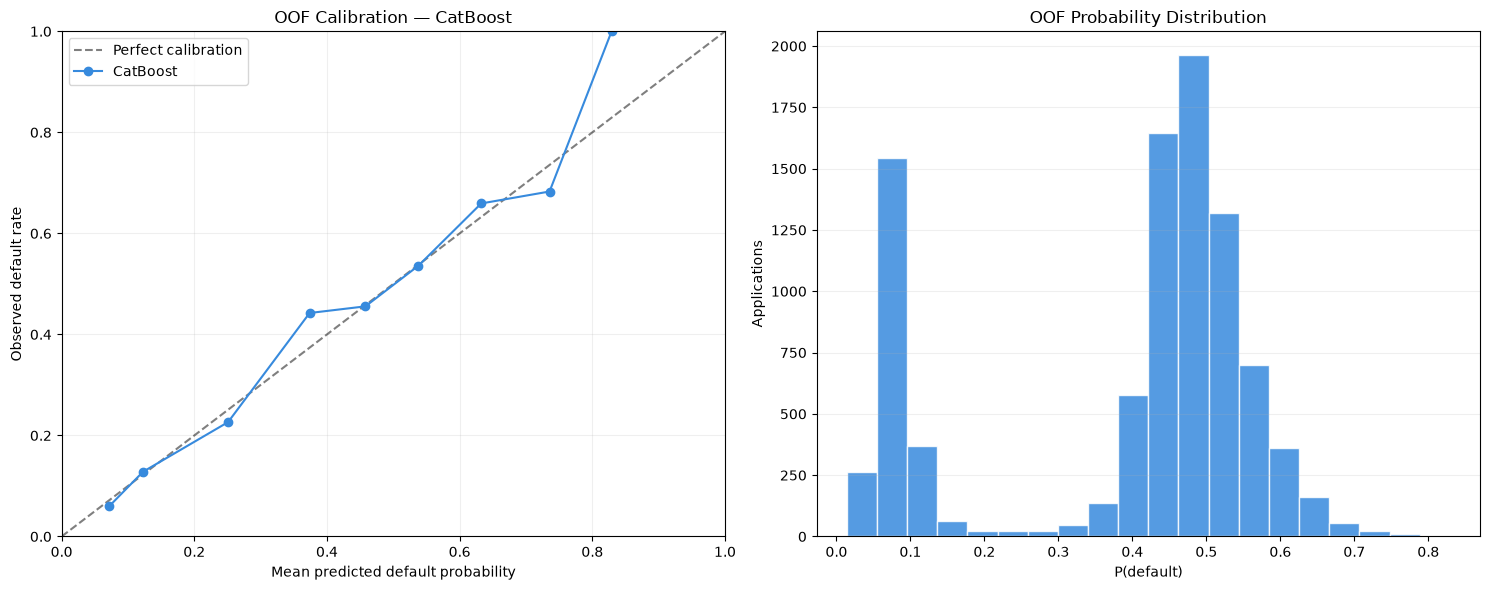

In [3]:
display(evaluation.calibration.round(4))
display(
    diagnostics_visualizer.calibration(
        evaluation.calibration,
        evaluation.oof_probability,
        benchmark_result.best_model_name,
    )
)

## 3. Business threshold

The threshold comes from the configured policy and out-of-fold probabilities only. Lowering it catches more defaults but also flags more customers who would repay.

Threshold policy: best_f1
Selected threshold: 0.2940
Threshold maximizing F1 on out-of-fold train predictions (F1=0.6513).


,Threshold,Defaults caught,Defaults missed,False positive alerts,Precision,Recall,False positive rate,Estimated cost,Additional defaults caught,Additional false alerts,Defaults caught per 100 extra false alerts,Selected
0,0.980,0,3636,0,0.0000,0.0000,0.0000,18180.0,0,0,NaN,False
1,0.940,0,3636,0,0.0000,0.0000,0.0000,18180.0,0,0,NaN,False
2,0.900,0,3636,0,0.0000,0.0000,0.0000,18180.0,0,0,NaN,False
3,0.860,0,3636,0,0.0000,0.0000,0.0000,18180.0,0,0,NaN,False
4,0.820,1,3635,0,1.0000,0.0003,0.0000,18175.0,1,0,NaN,False
5,0.780,4,3632,0,1.0000,0.0011,0.0000,18160.0,3,0,NaN,False
6,0.740,14,3622,3,0.8235,0.0039,0.0005,18113.0,10,3,333.3333,False
7,0.700,29,3607,13,0.6905,0.0080,0.0023,18048.0,15,10,150.0000,False
8,0.660,71,3565,37,0.6574,0.0195,0.0065,17862.0,42,24,175.0000,False
9,0.620,188,3448,102,0.6483,0.0517,0.0180,17342.0,117,65,180.0000,False


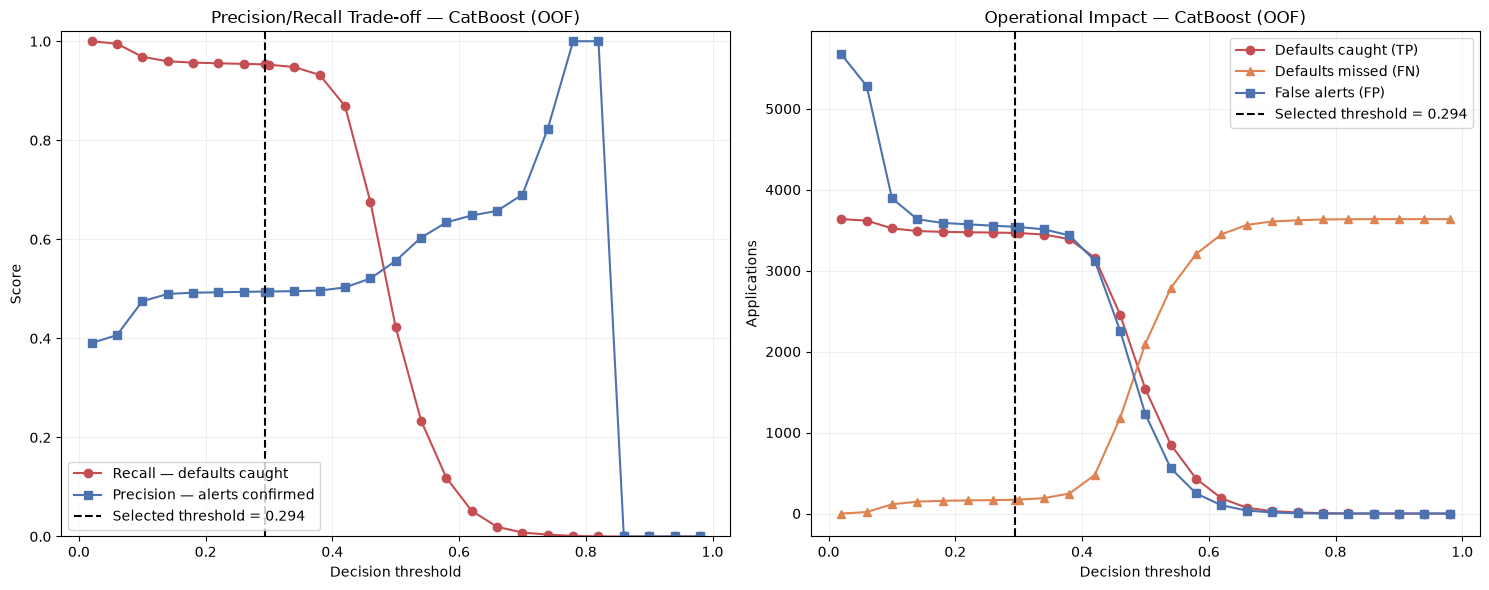

In [4]:
print(f"Threshold policy: {evaluation.threshold_details['policy']}")
print(f"Selected threshold: {evaluation.selected_threshold:.4f}")
print(evaluation.threshold_details["rationale"])
display(evaluation.threshold_tradeoff.round(4))
display(
    diagnostics_visualizer.threshold_tradeoff(
        evaluation.threshold_tradeoff,
        evaluation.selected_threshold,
        benchmark_result.best_model_name,
    )
)

## 4. Lift and cumulative gains

Risk group 1 contains the highest predicted risks. Lift measures how much more concentrated defaults are in each group than in the complete portfolio.

,Risk group,Applications,Defaults,Mean_probability,Default_rate,Lift,Cumulative_population,Cumulative_defaults_caught,Cumulative_lift
0,1,931,569,0.6098,0.6112,1.5649,0.1,0.1565,1.5649
1,2,931,527,0.5417,0.5661,1.4494,0.2,0.3014,1.5072
2,3,931,453,0.5110,0.4866,1.2459,0.3,0.4260,1.4201
3,4,931,451,0.4887,0.4844,1.2404,0.4,0.5501,1.3751
4,5,931,429,0.4701,0.4608,1.1799,0.5,0.6680,1.3361
5,6,931,429,0.4510,0.4608,1.1799,0.6,0.7860,1.3100
6,7,931,393,0.4266,0.4221,1.0809,0.7,0.8941,1.2773
7,8,931,274,0.2636,0.2943,0.7536,0.8,0.9695,1.2118
8,9,931,65,0.0834,0.0698,0.1788,0.9,0.9873,1.0971
9,10,931,46,0.0596,0.0494,0.1265,1.0,1.0000,1.0000


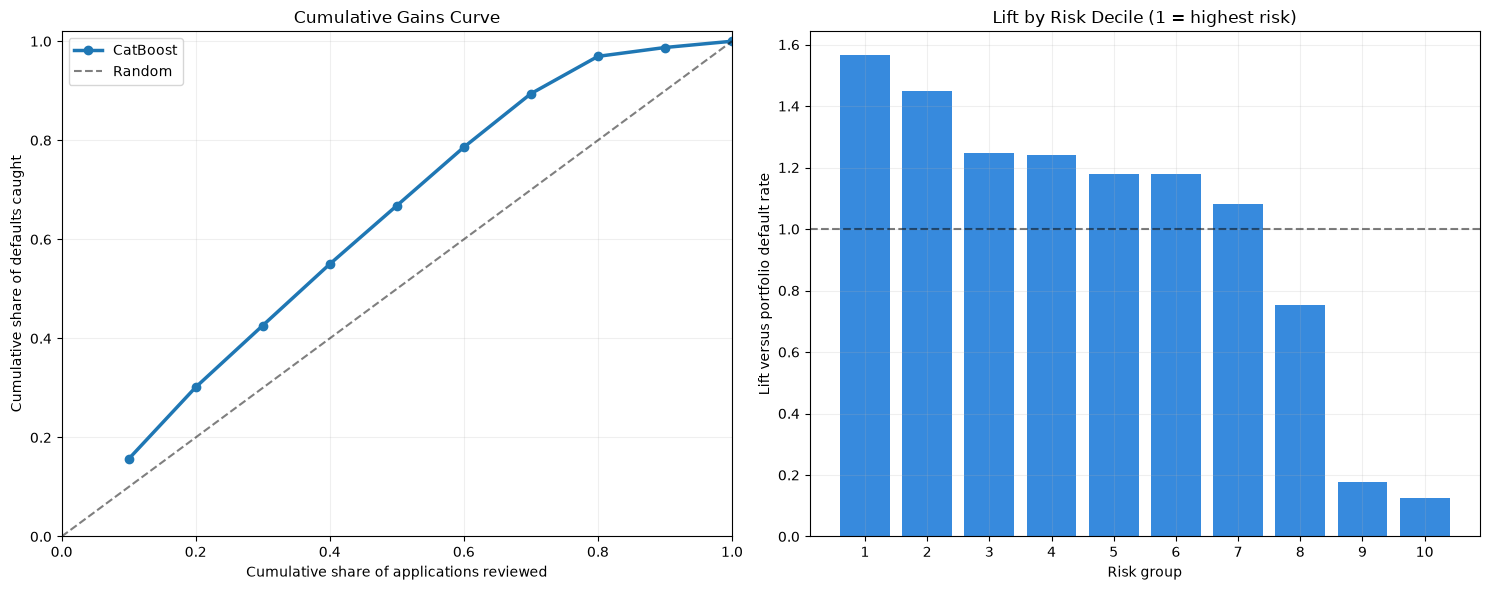

In [5]:
display(evaluation.lift_and_gains.round(4))
display(
    diagnostics_visualizer.lift_and_gains(
        evaluation.lift_and_gains,
        benchmark_result.best_model_name,
    )
)

## 5. Native feature importance

Native importance describes how effectively the trees used each feature. SHAP in the next section explains direction and magnitude, so these two views should not be confused.

,Importance
Feature,
credit_score,53.953915
monthly_income,10.222622
debt_to_income_ratio,6.065210
app_usage_frequency,5.310324
product_category,5.072900
employment_type,4.303391
bnpl_installments,4.179657
age,3.950164
location,3.604094


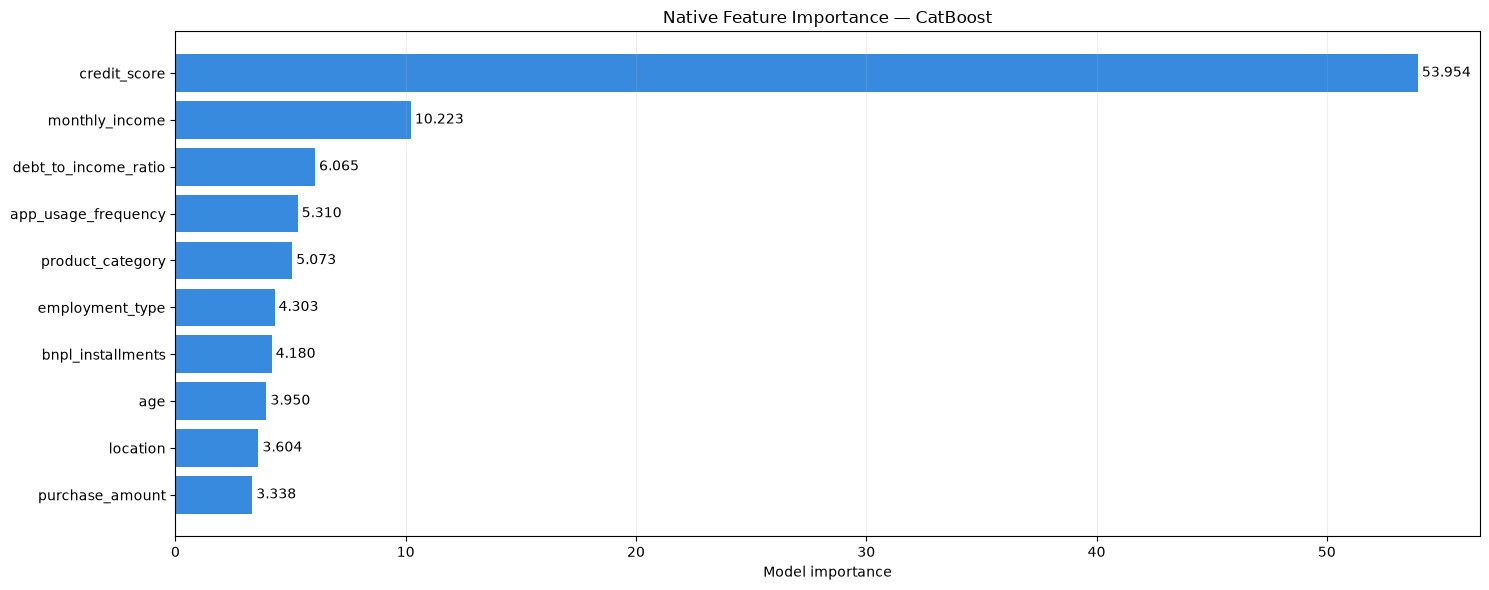

In [6]:
display(evaluation.feature_importance.rename_axis("Feature").to_frame())
display(
    diagnostics_visualizer.feature_importance(
        evaluation.feature_importance,
        benchmark_result.best_model_name,
        top_n=config.model.benchmark.visualization.top_n_features,
    )
)

## 6. SHAP explanations

These views use native TreeSHAP values: global mean impact, beeswarm direction, one local waterfall and dependence for the most influential feature. No separate `shap` package is required.

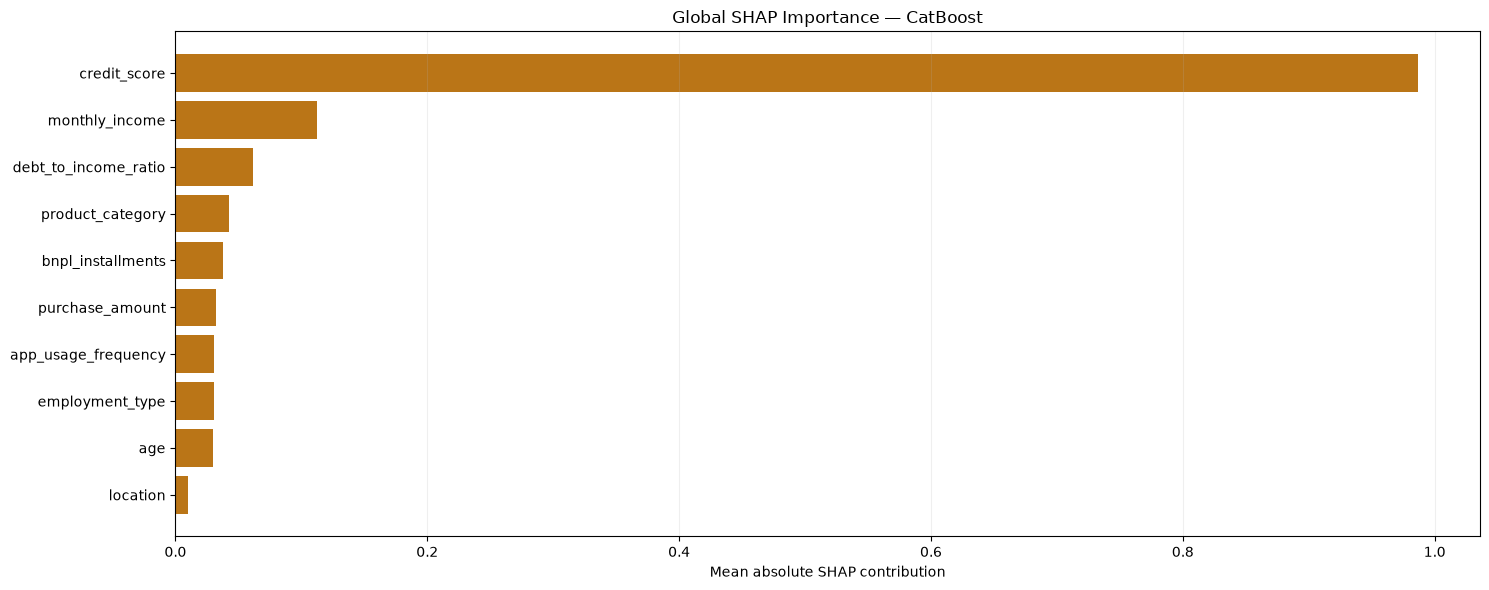

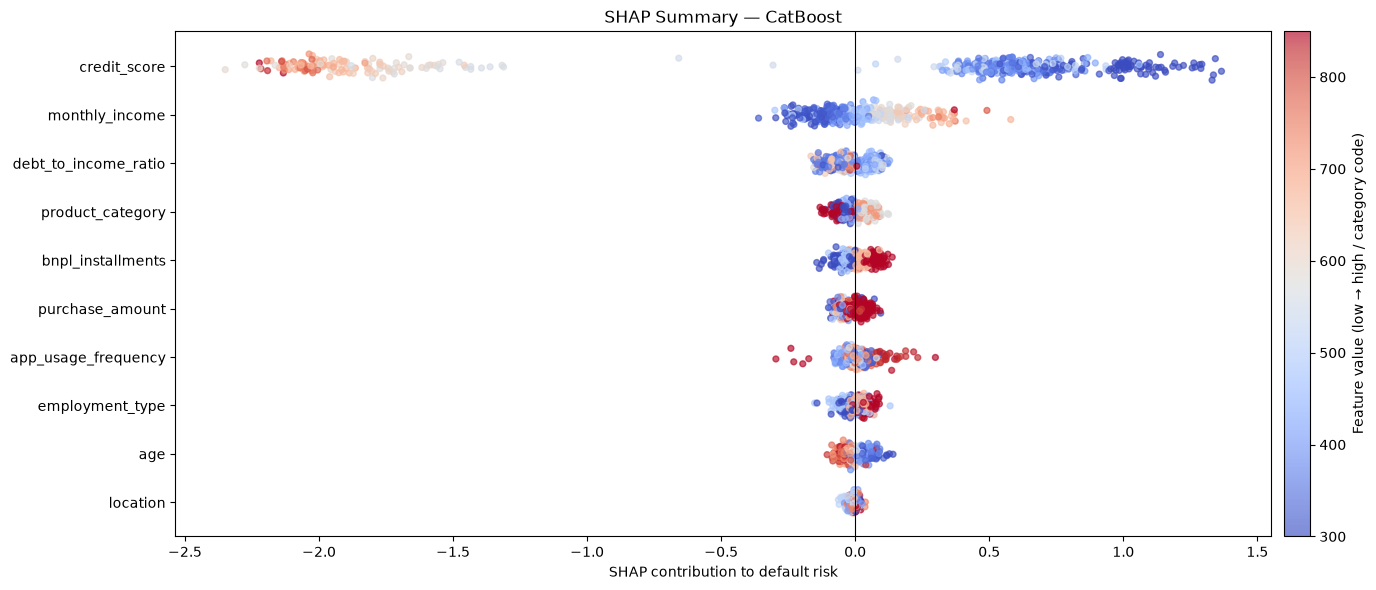

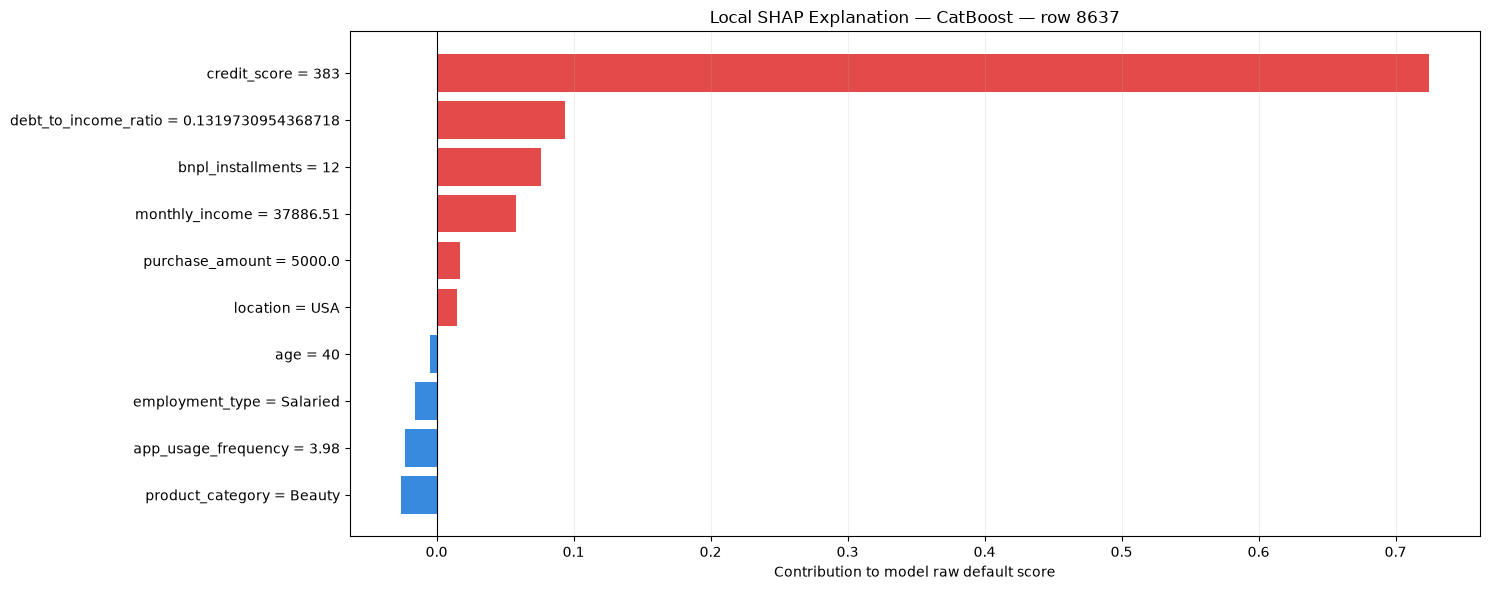

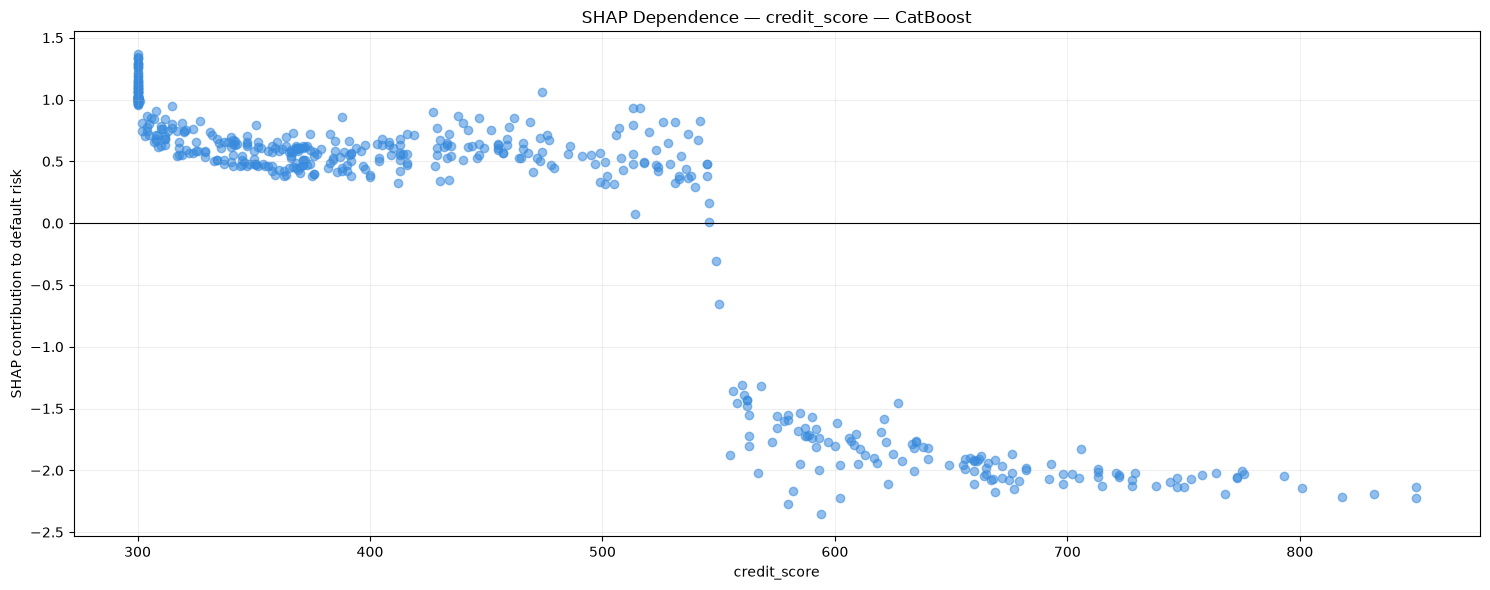

In [7]:
shap_top_n = config.model.benchmark.visualization.shap_top_n
dependence_feature = (
    evaluation.shap.values.abs().mean().sort_values(ascending=False).index[0]
)

display(
    diagnostics_visualizer.shap_global_bar(
        evaluation.shap, benchmark_result.best_model_name, top_n=shap_top_n
    )
)
display(
    diagnostics_visualizer.shap_beeswarm(
        evaluation.shap, benchmark_result.best_model_name, top_n=shap_top_n
    )
)
display(
    diagnostics_visualizer.shap_waterfall(
        evaluation.shap,
        benchmark_result.best_model_name,
        row_position=0,
        top_n=shap_top_n,
    )
)
display(
    diagnostics_visualizer.shap_dependence(
        evaluation.shap,
        dependence_feature,
        benchmark_result.best_model_name,
    )
)

## 7. Final test evaluation — run once

Run this cell only after accepting the selected model, calibration diagnosis and threshold. This is the first operation that opens `test_features.csv`.

2026-08-28 13:11:15.675 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/processed/test_features.csv rows=1035 columns=22


,ROC-AUC,PR-AUC,Precision,Recall,F1 score,MCC,Brier score,Log loss
OOF selected model,0.7066,0.5580,0.4946,0.9532,0.6513,0.3722,0.2020,0.5796
Final test,0.7144,0.5842,0.4875,0.9208,0.6375,0.3338,0.2051,0.5919


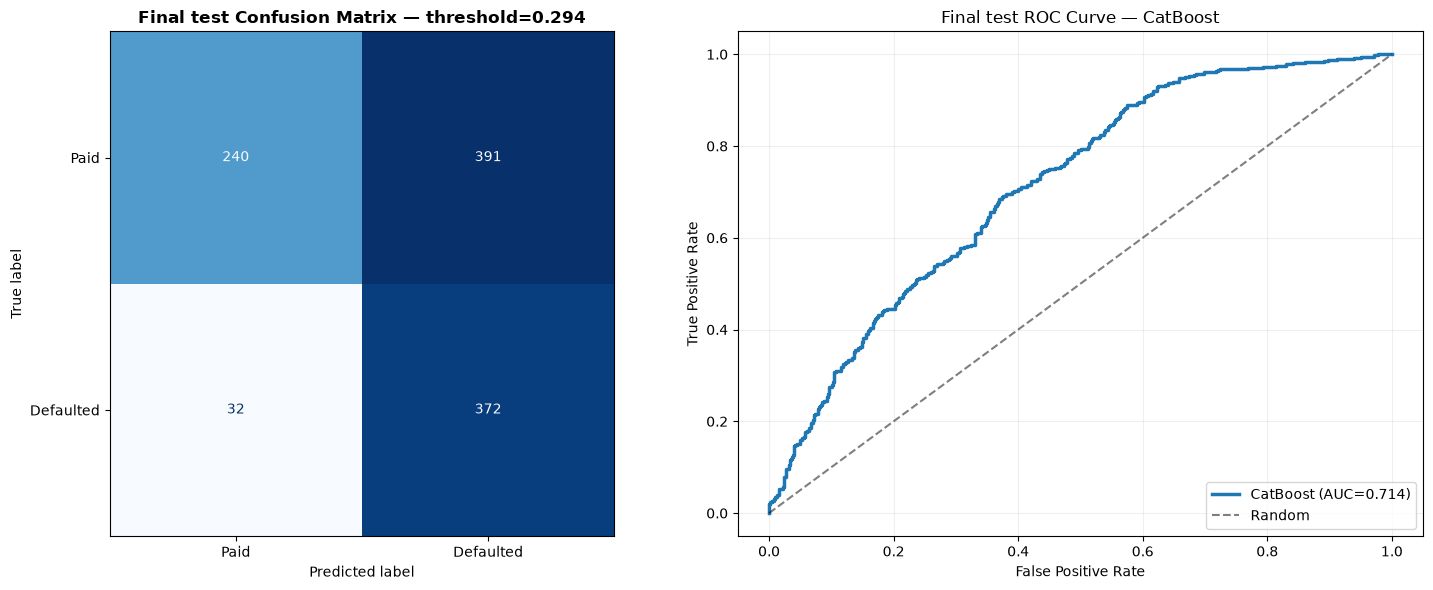

In [8]:
final_test = evaluation_pipeline.evaluate_test(evaluation)
display(final_test.metrics.round(4))
display(
    diagnostics_visualizer.classification_performance(
        final_test.y_test,
        final_test.probability,
        benchmark_result.best_model_name,
        threshold=evaluation.selected_threshold,
        dataset_label="Final test",
    )
)

## 8. Publish the approved model for inference

Run this cell only after accepting the final test result. It publishes the selected estimator, its training-only category vocabulary, the locked threshold, risk bands, metrics and feature contract. Notebook 06 only consumes this approved artifact.

In [9]:
approved_model_dir = evaluation_pipeline.publish(evaluation, final_test)
print(f"Approved model published: {approved_model_dir}")
print(f"MLflow run ID: {evaluation_pipeline.last_mlflow_run_id}")
print(f"MLflow registry version: {evaluation_pipeline.last_mlflow_registry_version}")
print(f"MLflow experiment: {config.training.mlflow.experiment_name}")
print("Next step: notebooks/06_batch_inference.ipynb")

2026-08-28 13:11:16.013 | INFO     | bnpl_credit_risk.models.persistence:save:61 - Saved model artifact version=2026-08-28_131115 dir=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/artifacts/models/2026-08-28_131115


Approved model published: /Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/artifacts/models/2026-08-28_131115
MLflow run ID: 60effccb46664e13b64f241040601a05
MLflow experiment: bnpl_credit_risk
Next step: notebooks/06_batch_inference.ipynb
